LAB EXERCISE 1 — Probability by Simulation
P(both heads) = 0.2498
P(at least one head) = 0.7494
P(0)+P(1)+P(2) = 1.0

LAB EXERCISE 2 — Conditional Probability
P(odd | <4) = 0.6622
P(<4) = 0.5008
P(odd) = 0.4977
Independent? False

LAB EXERCISE 3 — Bayes Theorem
P('free') = 0.16
P(spam | 'free') = 0.75

LAB EXERCISE 4 — Distributions
Poisson Mean = 2.0089


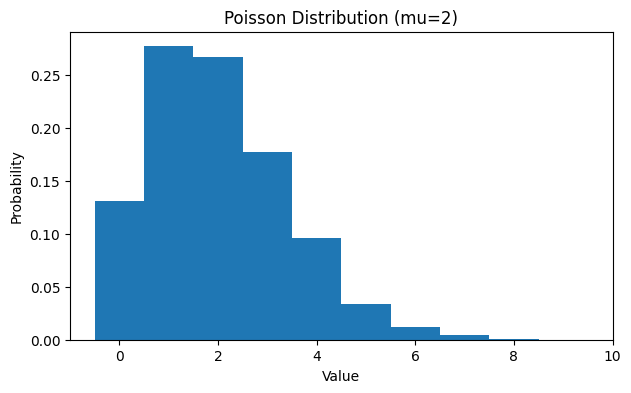

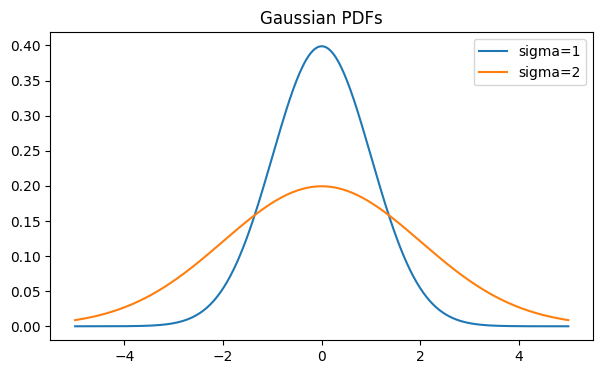


LAB EXERCISE 5 — Information Theory
Entropy (4-sided die): 2.0 bits
Entropy (6-sided die): 2.585 bits
More uncertain: 6-sided die

D(P || Q) = 0.1187 bits

Mutual Information Scores:
petal length (cm)   : 0.9896
petal width (cm)    : 0.9749
sepal length (cm)   : 0.4739
sepal width (cm)    : 0.2861

Most Informative Feature: petal length (cm)
Least Informative Feature: sepal width (cm)

All U6 Part-2 Lab Exercises Completed Successfully!


In [2]:
# ============================================================
# U6 — Probability & Statistics (Part 2)
# Complete Solutions for LAB EXERCISES 1–5
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import entropy
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

np.random.seed(42)

print("="*60)
print("LAB EXERCISE 1 — Probability by Simulation")
print("="*60)

flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)

# 1. P(both heads)
p_both_heads = (heads == 2).mean()
print("P(both heads) =", round(p_both_heads, 4))

# 2. P(at least one head)
p_at_least_one = (heads >= 1).mean()
print("P(at least one head) =", round(p_at_least_one, 4))

# 3. Check probabilities sum to 1
p0 = (heads == 0).mean()
p1 = (heads == 1).mean()
p2 = (heads == 2).mean()

print("P(0)+P(1)+P(2) =", round(p0+p1+p2, 4))

# ============================================================
# LAB EXERCISE 2
# Conditional Probability
# ============================================================

print("\n" + "="*60)
print("LAB EXERCISE 2 — Conditional Probability")
print("="*60)

rolls = np.random.randint(1, 7, size=100_000)

# 1. P(odd | roll < 4)
less4 = rolls < 4
p_odd_given_less4 = (rolls[less4] % 2 == 1).mean()

print("P(odd | <4) =", round(p_odd_given_less4, 4))

# 2. P(roll < 4)
p_less4 = less4.mean()
print("P(<4) =", round(p_less4, 4))

# 3. Independence
p_odd = (rolls % 2 == 1).mean()

print("P(odd) =", round(p_odd, 4))
print("Independent?",
      np.isclose(p_odd_given_less4,
                 p_odd,
                 atol=0.02))

# ============================================================
# LAB EXERCISE 3
# Bayes Theorem
# ============================================================

print("\n" + "="*60)
print("LAB EXERCISE 3 — Bayes Theorem")
print("="*60)

p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham = 0.05

# Total probability
p_free = (
    p_free_given_spam * p_spam
    + p_free_given_ham * (1 - p_spam)
)

# Bayes
p_spam_given_free = (
    p_free_given_spam * p_spam
) / p_free

print("P('free') =", round(p_free, 4))
print("P(spam | 'free') =", round(p_spam_given_free, 4))

# ============================================================
# LAB EXERCISE 4
# Distributions
# ============================================================

print("\n" + "="*60)
print("LAB EXERCISE 4 — Distributions")
print("="*60)

# 1. Poisson
pois = stats.poisson(mu=2).rvs(size=10000)

print("Poisson Mean =", round(pois.mean(), 4))

# 2. Histogram
plt.figure(figsize=(7,4))
plt.hist(
    pois,
    bins=np.arange(pois.max()+2)-0.5,
    density=True
)

plt.title("Poisson Distribution (mu=2)")
plt.xlabel("Value")
plt.ylabel("Probability")
plt.show()

# 3. Gaussian PDFs
x = np.linspace(-5, 5, 300)

plt.figure(figsize=(7,4))

for sigma in [1, 2]:
    plt.plot(
        x,
        stats.norm(0, sigma).pdf(x),
        label=f"sigma={sigma}"
    )

plt.title("Gaussian PDFs")
plt.legend()
plt.show()

# ============================================================
# LAB EXERCISE 5
# Information Theory
# ============================================================

print("\n" + "="*60)
print("LAB EXERCISE 5 — Information Theory")
print("="*60)

# 1. Entropy of fair dice

die4 = [1/4]*4
die6 = [1/6]*6

H4 = entropy(die4, base=2)
H6 = entropy(die6, base=2)

print("Entropy (4-sided die):",
      round(H4, 4), "bits")

print("Entropy (6-sided die):",
      round(H6, 4), "bits")

print("More uncertain:",
      "6-sided die" if H6 > H4 else "4-sided die")

# 2. KL Divergence

P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])

kl = entropy(P, Q, base=2)

print("\nD(P || Q) =",
      round(kl, 4), "bits")

# 3. Mutual Information

iris = load_iris()

mi = mutual_info_classif(
    iris.data,
    iris.target,
    random_state=0
)

feature_scores = sorted(
    zip(iris.feature_names, mi),
    key=lambda x: x[1],
    reverse=True
)

print("\nMutual Information Scores:")

for name, score in feature_scores:
    print(f"{name:20s}: {score:.4f}")

print("\nMost Informative Feature:",
      feature_scores[0][0])

print("Least Informative Feature:",
      feature_scores[-1][0])

print("\nAll U6 Part-2 Lab Exercises Completed Successfully!")